In [3]:
#%pip install -q numpy opencv-python matplotlib pillow

In [4]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
%matplotlib inline

def cv2_imshow(img):
    plt.figure()
    if len(img.shape) == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

## Intro

Linear algebra is fundamental in many fields, particularly in classical computer vision. This is because every image can be represented as a matrix, and matrices represent linear transformations. As a result, we can apply known linear transformations to images!

This lab provides an overview of linear transformations, their proofs, and how to apply them to images to visualize their effects.





## Rules
1. Submit this task as a Jupyter Notebook (.ipynb file). No GitHub or Google Colab links are accepted.

2. Please use cv2 standard methods for reading and resizing the images, and matplotlib or cv2 imshow function for displaying it.

3. There should be only one submission per team. Choose **one** person from your team who would submit the task, and **make sure that the names of all team members are listed in the notebook**. Teammates not mentioned in the notebook will not be graded for this lab.  

4. Provide a **work breakdown** structure estimating the efforts of each team member. Please provide it at the top of your notebook.  

5. Please note that your final mark for this assignment will consist of three components:
  *   **Coding part**. This includes the implementation of the required transformations, the correctness and quality of the code. Plagiarism in code will lead to a grade reduction for all team members.
  *   **Explanations**. This includes the clarity and correctness of your theoretical explanations. Make sure to answer all of the theoretical questions in detail. When using mathematical notation, please use LaTeX syntax (enclosed in dollar signs `$...$` for inline math, and double dollar signs `$$...$$` for display math). Avoiding using LaTeX syntax is harder to type, read, and understand, and it may lead to loss of points as well. Plagiarism in your explanations will lead to a grade reduction for all team members.
  *   **Oral defense**. The time slots for this will soon be announced. Make sure that all team members are available during your chosen time slots. The oral defense will include questions about your implementation, both from a list that will be provided in advance and spontaneous questions from the assistants. This part will be made up of your personal grade and your team grade.
  
6. **Important**: during the implementation, you are welcomed to use `cv2` methods, but you must also implement the transformation matrices yourself (except image **reading**, **resizing** and **displaying**). Finally, as a successful result, you can demonstrate that the outputs of both approaches coincide.

7. The deadline for this lab is November 23rd, 8:00. If you submit your assignment after this time and date, it will not be graded. Please plan your time accordingly as there will be no extensions or exceptions for the lab deadline.

#### Work breakdown:

Zahar Veresniuk: Task 1.1 - 1.3

Mykola Balyk: Task 1.4 - 1.6

Mykhailo Rykhalskyi: Task 2

Mariia Hamaniuk: Task 3

## OpenCV library

In this laboratory work, we advise you to use `OpenCV` to process images. This is a popular library used for working with images and videos. It provides many tools for tasks like image processing, object detection, and analyzing video.

There are some things about `OpenCV` that you should know before starting the lab and which will save you a lot of time debugging your code:

* **Coordinate System**

In `OpenCV`, the coordinate system starts at the top-left corner of the image:

- X-axis increases from left to right.
- Y-axis increases from top to bottom.

(add image here)

So, the point $(0,0)$ is at the top-left of the image, and the point at the bottom-right is $(W-1, H-1)$, where $H$ is the height, $W$ is the width.

* **Color Channels**

`OpenCV` uses the BGR (Blue, Green, Red) color format by default, unlike many other libraries that use RGB (Red, Green, Blue). This means that when you read an image using `cv2.imread()`, the channels are ordered as Blue, Green, and Red.

<br>

Some basic information about its methods with examples you can find here: https://www.geeksforgeeks.org/opencv-python-tutorial/#2-working-with-images
## Task 1

Recall that a linear transformation is a mapping $T: \mathbb{R}^n \rightarrow \mathbb{R}^m$ such that
$\forall c_1, c_2 \in \mathbb{R}, \mathbf{u}_1, \mathbf{u}_2 \in \mathbb{R}^n$  
$T(c_1 \mathbf{u}_1 + c_2 \mathbf{u}_2) = c_1T(\mathbf{u}_1) + c_2T(\mathbf{u}_2)$.  

In this lab you will study some of the common transformations in $\mathbb{R}^2$, derive their general matrix form, explain what a resulting image will look like and apply transformations to the vectors and pictures.

Each linear transformation can be represented as a matrix. In case of an image linear transformation is applied to a pixel position on xy-plane, transforming its coordinates $(x, y)$ to $(x', y')$ but retaining the color. However, the image is usually represented as an array of pixels, thus having the dimension (image height, image width, 3) if the color is represented in RGB system. 

In this task, you should:

* use `warpAffine()` function from `cv2` library to apply transformations to images
* use your own implementation of applying transformations to each pixel position in the image array

The first approach will help you to verify the correctness of your implementation, as well as teach you how to use the `cv2` library in real applications. The second approach will help you to understand how linear transformations work. Think about how to more accurately check the correctness of your implementation rather than just visual comparison of the resulting images.

### What is a transformation matrix?

A transformation matrix is an $m \times n$ matrix $A$ that algebraically represents a linear transformation $T$ between two vector spaces, such that applying the transformation to a vector $\mathbf{x}$ is evaluated strictly through matrix-vector multiplication: $T(\mathbf{x}) = A\mathbf{x}$.

### 1.1 Image preparation

First, load image 1, resize it to a more convenient form, and examine its representation.

The shape of the image is (500, 500, 3)


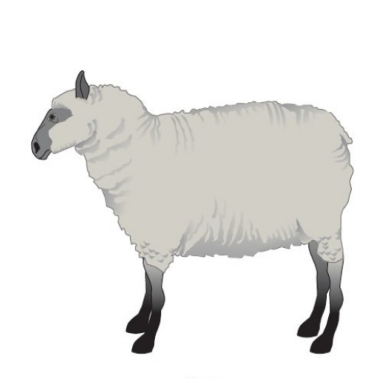

In [5]:
img1_path = './sheep.png'
image = cv.imread(img1_path)
resized = cv.resize(image, (500, 500))

print(f"The shape of the image is {resized.shape}")
cv2_imshow(resized)

 What is this image's shape? What do the values mean?

The shape is (500, 500, 3): height × width × 3 color channels. OpenCV stores channels in BGR order. Each value is an integer in [0, 255] representing the intensity of that channel.

### 1.2 Scaling matrix

Scaling is a tranformation that enlarges or diminishes objects by a factor. For scaling in 2D space a factor can be represented as a vector $(x_s, y_s)$ where $x_s$ and $y_s$ are scaling factors for each respective axis (those factors don't have to be equal). On the picture below, V' represents vector V scaled by a factor (0.5, 1) and V'' - by (0.5, 0.5).
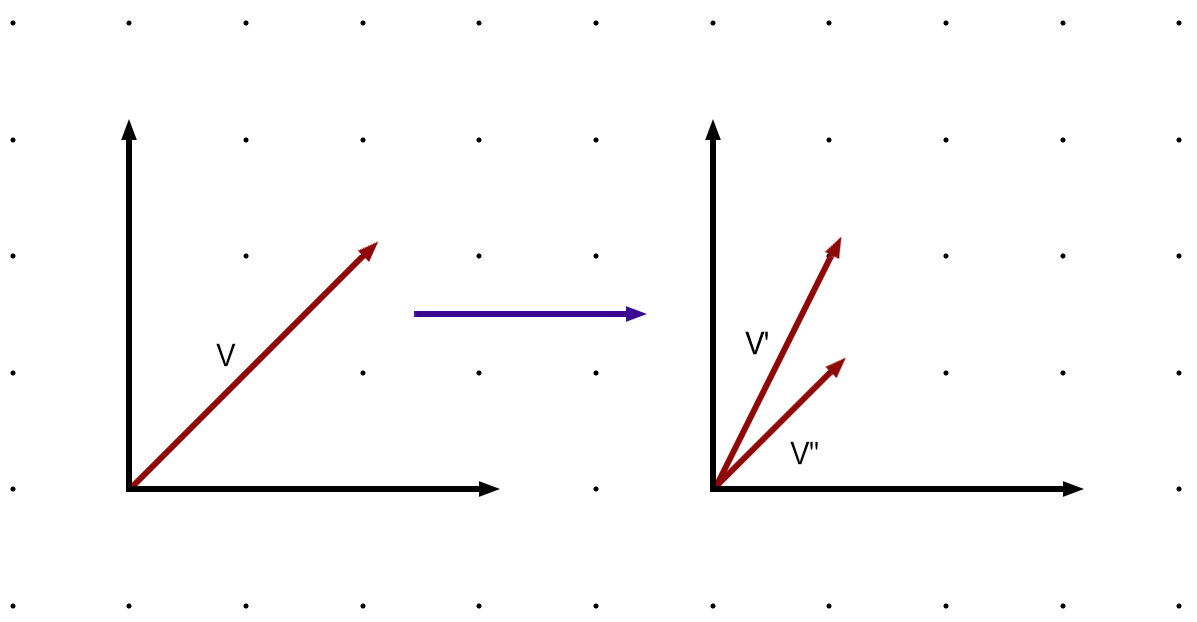

In this part, you should derive a general form for a scaling matrix and apply scaling by a factor of (1, 0.5) to the vector. First, explain how you derive the scaling matrix:

We want S·[x, y]ᵀ = [sx·x, sy·y]ᵀ. Matching coefficients gives S = [[sx, 0], [0, sy]].

In [6]:
def get_scaling_matrix(scale_factor_x, scale_factor_y):
    return np.array([[scale_factor_x, 0],
                     [0, scale_factor_y]], dtype=np.float64)

M2 = get_scaling_matrix(1, 0.5)

Second, apply scaling by (1, 0.5) to the vector.

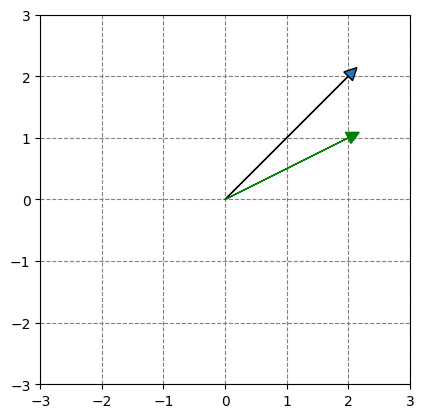

In [7]:
# Apply scaling to the vector AB1 to achieve vector AB2

##### YOUR CODE STARTS #####
A  = np.array([0, 0])
B1 = np.array([2, 2])
B2 = M2 @ B1
##### YOUR CODE ENDS #####

ax = plt.axes()

ax.arrow(A[0], A[1], B1[0], B1[1], head_width=0.2, head_length=0.2)
ax.arrow(A[0], A[1], B2[0], B2[1], head_width=0.2, head_length=0.2, color='green')
plt.ylim(-3,3)
plt.xlim(-3,3)

ax.set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

Now, apply scaling by some factor to the image (scaled by a factor of (1, 0.5) before) to restore the **sheep.png**:

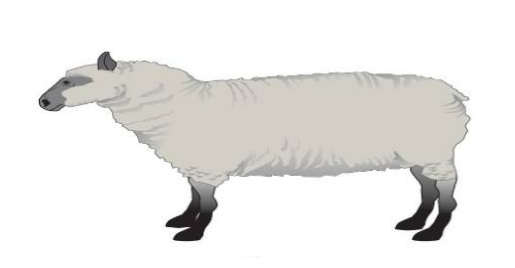

In [8]:
scaled_img = cv.imread("./scaled_sheep.png")
cv2_imshow(scaled_img)

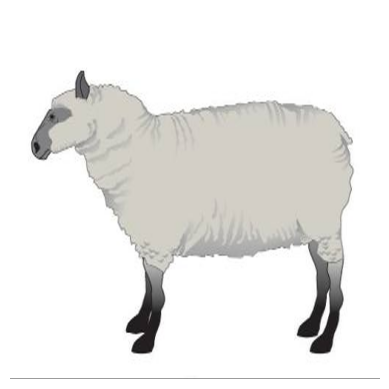

In [9]:
##### YOUR CODE STARTS #####
M_restore = get_scaling_matrix(1.0, 2.0)
M_affine  = np.hstack([M_restore, np.zeros((2, 1))])

h, w = scaled_img.shape[:2]

new_w = int(w * 1.0)
new_h = int(h * 2.0)

restored_img = cv.warpAffine(scaled_img, M_affine, (new_w, new_h), flags=cv.INTER_CUBIC)
##### YOUR CODE ENDS #####
cv2_imshow(restored_img)

### 1.3 Shear matrix

Horizontal shearing moves each point in a fixed direction by distance proportional to y-coordinate of the point. Shear map changes angles and lengths of line segments.

In this part, you need to build a shearing matrix, find a transformation matrix that moves the point $(x, y)$ to $(x+1.5y, y)$, and apply it to the vector. First, explain how do you build a matrix that corresponds to a shearing transformation:

Horizontal shear maps (x, y) → (x + m·y, y). So H = [[1, m], [0, 1]].

Second, implement a function for constructing such a matrix:

In [10]:
##### YOUR CODE STARTS #####
def get_horizontal_shear_matrix(factor):
    return np.array([[1, factor],
                     [0, 1]], dtype=np.float64)

M3 = get_horizontal_shear_matrix(1.5)
##### YOUR CODE ENDS #####
print("Shearing matrix is")
print(M3)

Shearing matrix is
[[1.  1.5]
 [0.  1. ]]


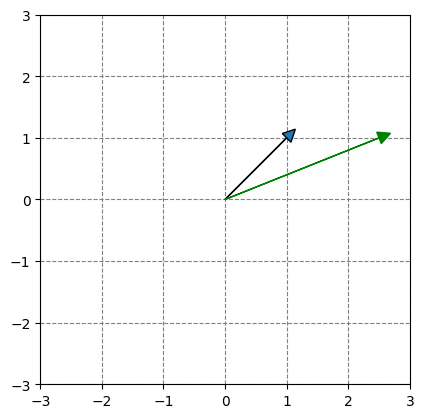

In [11]:
# Apply shearing to the vector AB1 to achieve vector AB2

##### YOUR CODE STARTS #####
A  = np.array([0, 0])
B1 = np.array([1, 1])
B2 = M3 @ B1   # → [2.5, 1]
##### YOUR CODE ENDS #####

ax = plt.axes()

ax.arrow(A[0], A[1], B1[0], B1[1], head_width=0.2, head_length=0.2)
ax.arrow(A[0], A[1], B2[0], B2[1], head_width=0.2, head_length=0.2, color='green')
plt.ylim(-3,3)
plt.xlim(-3,3)

ax.set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

Finally, apply this shearing transformation to the image (transformed with vertical shearing) to restore **sheep.png**.

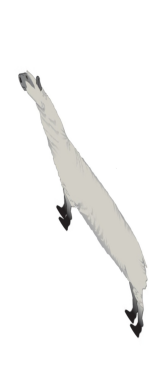

In [12]:
sheared_img = cv.imread("./sheared_sheep.png")
cv2_imshow(sheared_img)

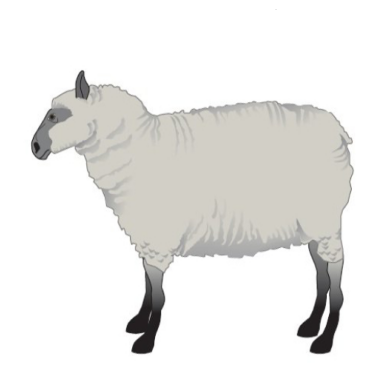

In [13]:
##### YOUR CODE STARTS #####
M_restore = get_horizontal_shear_matrix(-1.5).T
M_affine = np.hstack([M_restore, np.zeros((2, 1))])

restored_img = cv.warpAffine(sheared_img, M_affine, (500, 500), flags=cv.INTER_CUBIC)

##### YOUR CODE ENDS #####
cv2_imshow(restored_img)

### 1.4 Translation matrix

Translation is a transformation that moves every point of a figure by a fixed distance.


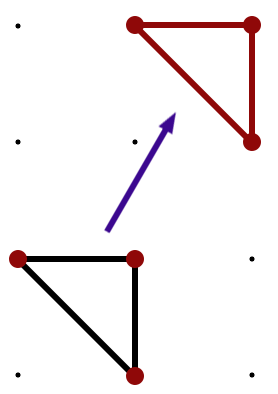

Here, you should build a translation matrix and apply translation by $(20, 25)$ to the vector. Start from explaining how to construct a translation matrix:

For 2D translation, we use **homogeneous coordinates**. A point $(x, y)$ is written as $(x, y, 1)^T$ and translated by $(t_x, t_y)$ with:

$$
T(t_x,t_y)=\begin{bmatrix}
1 & 0 & t_x \\
0 & 1 & t_y \\
0 & 0 & 1
\end{bmatrix}
$$

Then

$$
\begin{bmatrix}x'\\y'\\1\end{bmatrix}=T(t_x,t_y)\begin{bmatrix}x\\y\\1\end{bmatrix}=\begin{bmatrix}x+t_x\\y+t_y\\1\end{bmatrix}.
$$

So translation by $(20,25)$ adds 20 to every $x$ coordinate and 25 to every $y$ coordinate.

Then, implement a function that produces such a matrix:

In [14]:
##### YOUR CODE STARTS #####
def get_translation_matrix(translation_factor_x, translation_factor_y):
  return np.array([
      [1, 0, translation_factor_x],
      [0, 1, translation_factor_y],
      [0, 0, 1]
  ], dtype=np.float32)

M4 = get_translation_matrix(20, 25)
##### YOUR CODE ENDS #####
print("Translation matrix is")
print(M4)

Translation matrix is
[[ 1.  0. 20.]
 [ 0.  1. 25.]
 [ 0.  0.  1.]]


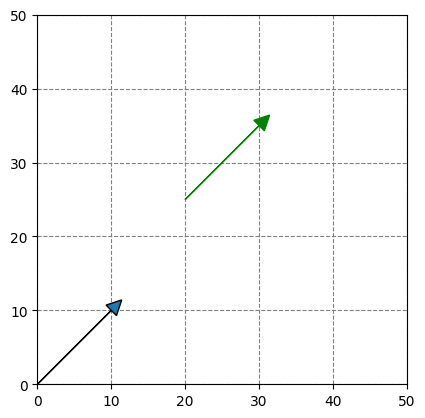

In [15]:
# Apply translation to the vector A1B1 to achieve vector A2B2

##### YOUR CODE STARTS #####
A1 = np.array([0, 0])
B1 = np.array([10, 10])

A1_h = np.array([A1[0], A1[1], 1], dtype=np.float32)
B1_h = np.array([B1[0], B1[1], 1], dtype=np.float32)

A2 = (M4 @ A1_h)[:2]
B2 = (M4 @ B1_h)[:2]
##### YOUR CODE ENDS #####

ax = plt.axes()

ax.arrow(A1[0], A1[1], B1[0], B1[1], head_width=2, head_length=2)
ax.arrow(A2[0], A2[1], B2[0]-A2[0], B2[1]-A2[1], head_width=2, head_length=2, color='green')
plt.ylim(0,50)
plt.xlim(0,50)

ax.set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

Finally, apply the translation to the image (translated by (20, 25) before) to restore **sheep.png**.






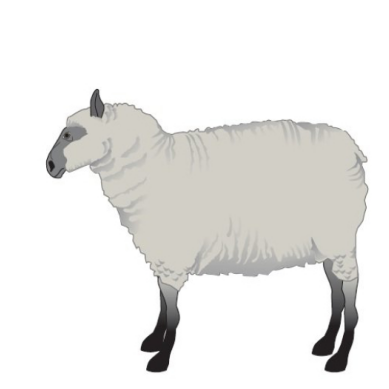

In [16]:
translated_img = cv.imread("./translated_sheep.png")
cv2_imshow(translated_img)

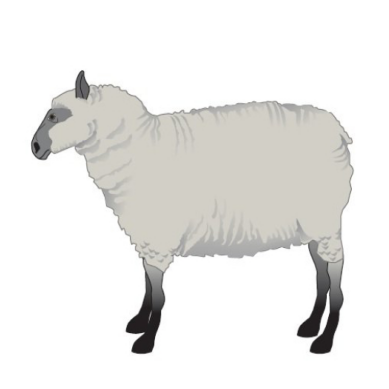

In [17]:
##### YOUR CODE STARTS #####
M_restore = get_translation_matrix(-20, -25)
restored_img = cv.warpPerspective(
    translated_img,
    M_restore,
    (translated_img.shape[1], translated_img.shape[0]),
    flags=cv.INTER_CUBIC,
    borderMode=cv.BORDER_CONSTANT, 
    borderValue=(255,255,255),
    )
##### YOUR CODE ENDS #####
cv2_imshow(restored_img)

### 1.5 Rotation matrix

Rotation is a linear transformation of some space that preserves at least one point. An example of rotation by angle $\psi$ on xy-plane is depicted on the image below:   
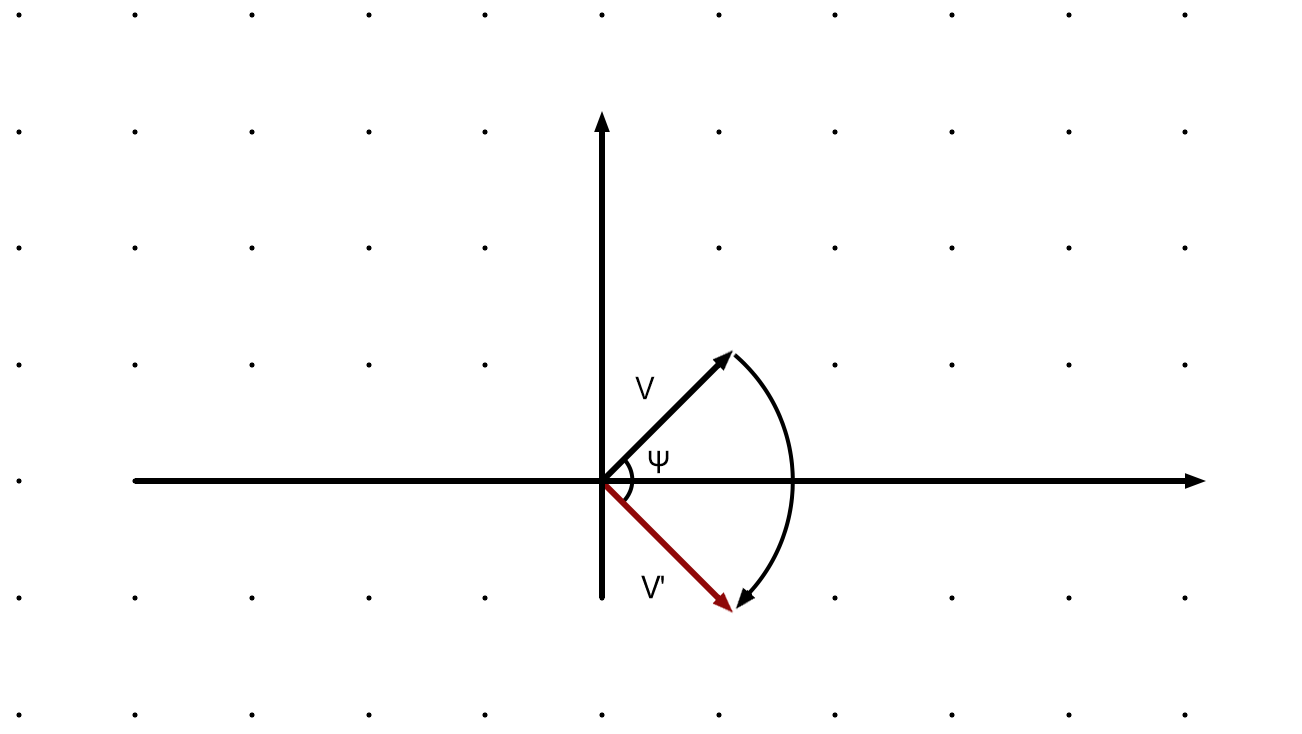

Derive the transformation matrix that corresponds to rotation by a generic angle $\phi$?

For a counterclockwise rotation by angle $\phi$ around the origin, coordinates transform as

$$
\begin{aligned}
x' &= x\cos\phi - y\sin\phi,\\
y' &= x\sin\phi + y\cos\phi.
\end{aligned}
$$

So the rotation matrix is

$$
R(\phi)=\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}.
$$

If we rotate by $45^\circ$, we substitute $\phi=45^\circ$ (or $\pi/4$ radians) into this matrix.

Your next task is to implement a function that calculates the rotation matrix and apply it to a vector to rotate it by $45^\circ$.
First, construct the rotation matrix:

In [18]:
# Create rotation matrix

def get_rotation_matrix(phi):
  ##### YOUR CODE STARTS #####
  phi_rad = np.deg2rad(phi)
  transformation_matrix = np.array([
      [np.cos(phi_rad), -np.sin(phi_rad)],
      [np.sin(phi_rad),  np.cos(phi_rad)]
  ], dtype=np.float32)
  ##### YOUR CODE ENDS #####
  return transformation_matrix

phi = 45
M = get_rotation_matrix(phi)
print("Rotation matrix is")
print(M)

Rotation matrix is
[[ 0.70710677 -0.70710677]
 [ 0.70710677  0.70710677]]


Second, we'll apply the transformation to a vector. Let's check what our vector looks like now:


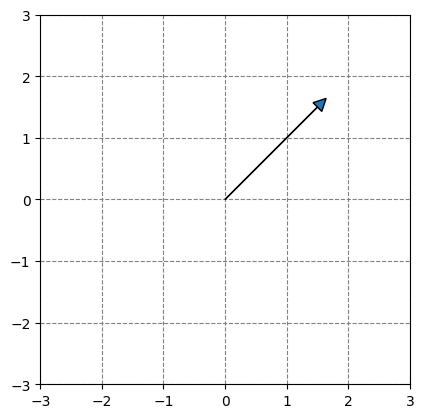

In [19]:
A = np.array([0, 0])
B1 = np.array([1.5, 1.5])

ax = plt.axes()

ax.arrow(A[0], A[1], B1[0], B1[1], head_width=0.2, head_length=0.2)
plt.ylim(-3,3)
plt.xlim(-3,3)

ax.set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

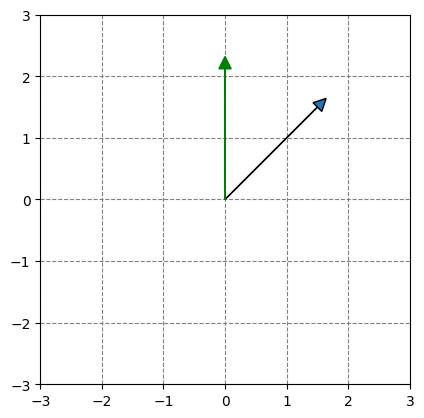

In [20]:
# Apply rotation to the vector AB1 to get vector AB2

##### YOUR CODE STARTS #####
A = np.array([0.0, 0.0])
B1 = np.array([1.5, 1.5], dtype=np.float32)
B2 = M @ B1
##### YOUR CODE ENDS #####

ax = plt.axes()

ax.arrow(A[0], A[1], B1[0], B1[1], head_width=0.2, head_length=0.2)
ax.arrow(A[0], A[1], B2[0], B2[1], head_width=0.2, head_length=0.2, color='green')
plt.ylim(-3,3)
plt.xlim(-3,3)

ax.set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

You can also rotate images! There is image rotated by 45 degrees. Rotate it back with transformation matrix, so it will look like **sheep.png**:

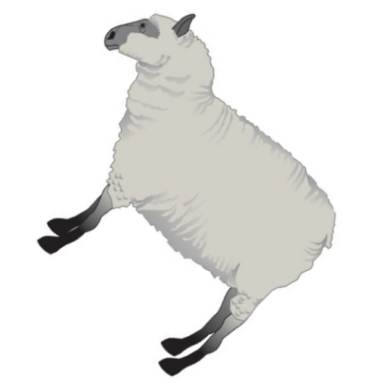

In [21]:
rotated_img = cv.imread("./rotated_sheep.png")
cv2_imshow(rotated_img)

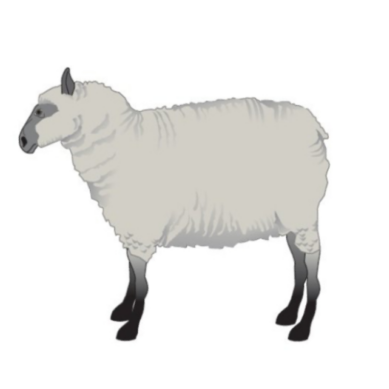

In [22]:
##### YOUR CODE STARTS #####
h, w = rotated_img.shape[:2]
cx, cy = w / 2.0, h / 2.0

R_restore = get_rotation_matrix(-45)
T_to_origin = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]], dtype=np.float32)
R_h = np.array([[R_restore[0,0], R_restore[0,1], 0],
                [R_restore[1,0], R_restore[1,1], 0],
                [0, 0, 1]], dtype=np.float32)
T_back = np.array([[1, 0, cx], [0, 1, cy], [0, 0, 1]], dtype=np.float32)

H_restore = T_back @ R_h @ T_to_origin
M_restore = H_restore[:2, :]

restored_img = cv.warpAffine(rotated_img, M_restore, (w, h), flags=cv.INTER_LINEAR, borderMode=cv.BORDER_CONSTANT, borderValue=(255, 255, 255))
##### YOUR CODE ENDS #####

cv2_imshow(restored_img)

### 1.6 Mirror symmetry
Vertical mirror symmetry maps coordinates $(x, y)$ to $(-x,y)$.

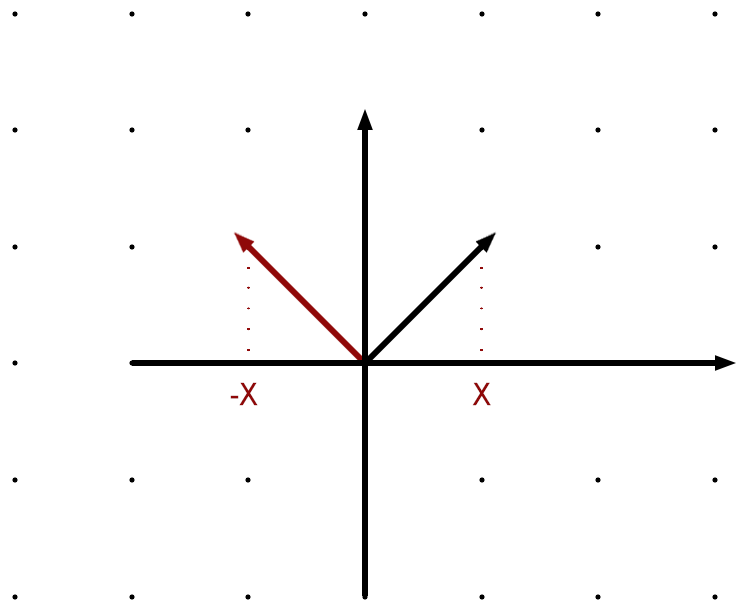

As in the previous parts, you need to provide the expanltion, implement a function that produces a vertical symmetry matrix, and apply it to the vector and to the image.

For vertical mirror symmetry (reflection across the **y-axis**), each point transforms as

$$
(x, y) \mapsto (-x, y).
$$

So the transformation matrix is

$$
M_{\text{mirror}}=\begin{bmatrix}
-1 & 0 \\
0 & 1
\end{bmatrix}.
$$

Applying it to a vector point $\mathbf{p}=[x,y]^T$ gives $\mathbf{p}'=M_{\text{mirror}}\mathbf{p}=[-x,y]^T$.
For images, the same reflection idea is used with an affine matrix that also includes translation to keep pixels inside image bounds.

In [23]:
##### YOUR CODE STARTS #####
def get_vertical_mirror_marix():
  return np.array([
      [-1, 0],
      [ 0, 1]
  ], dtype=np.float32)

M5 = get_vertical_mirror_marix()
##### YOUR CODE ENDS #####
print("Mirroring matrix is")
print(M5)

Mirroring matrix is
[[-1.  0.]
 [ 0.  1.]]


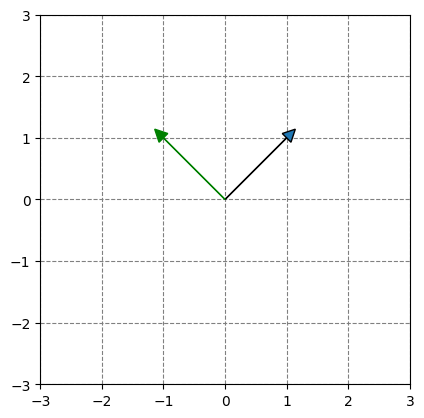

In [24]:
# Apply mirroring to the vector AB1 to achieve vector AB2

##### YOUR CODE STARTS #####
A = np.array([0.0, 0.0])
B1 = np.array([1, 1], dtype=np.float32)
B2 = M5 @ B1
##### YOUR CODE ENDS #####

ax = plt.axes()

ax.arrow(A[0], A[1], B1[0], B1[1], head_width=0.2, head_length=0.2)
ax.arrow(A[0], A[1], B2[0], B2[1], head_width=0.2, head_length=0.2, color='green')
plt.ylim(-3,3)
plt.xlim(-3,3)

ax.set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

Apply a vertical symmetry matrix to restore **sheep.png**.

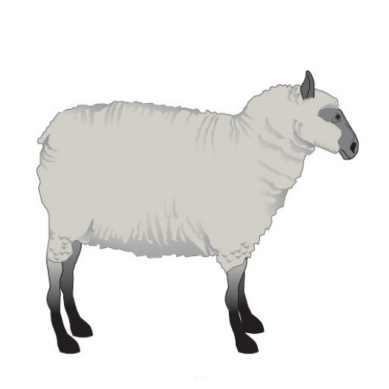

In [25]:
mirrored_img = cv.imread("./mirrored_sheep.png")
cv2_imshow(mirrored_img)

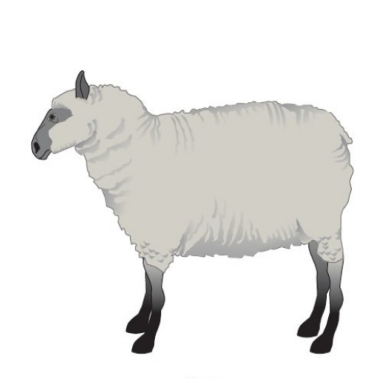

In [26]:
##### YOUR CODE STARTS #####
h, w = mirrored_img.shape[:2]
M_restore = np.array([
    [-1, 0, w - 1],
    [ 0, 1, 0]
], dtype=np.float32)

restored_img = cv.warpAffine(
    mirrored_img,
    M_restore,
    (w, h),
    flags=cv.INTER_LINEAR,
    borderMode=cv.BORDER_CONSTANT,
    borderValue=(255, 255, 255)
    )
##### YOUR CODE ENDS #####
cv2_imshow(restored_img)

## Task 2

### 2.1 Perspective shift (homography) matrix

You will need to use `img2.jpg` for this task. Load and resize it using the same commands you used for preparing img1.

The main goal of perspective transformation (or perspective rectification) is to synthesize a perspective-free view of an object given a photo taken at an angle.   

❗️We recommend reading more here: https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html.

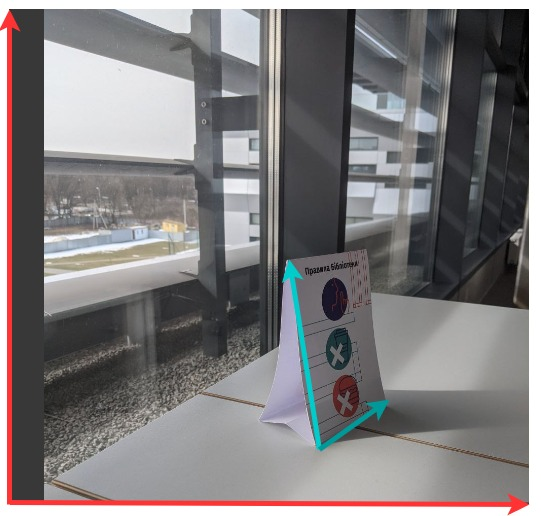

As you see on the picture above, the initial picture has a standard basis of red vectors. We want to transform all of the vectors in the picture so that the blue vectors will become the new basis.

To find this transformation matrix, you need to choose 4 points on the input image and corresponding points on the output image ($3$ of these points should not be collinear). Simply saying, you can choose these points using, for example, Paint.

Our goal is to find a transformation that maps each of our initial 4 points $(x_i,y_i)$ to 4 points with new coordinates $(u_i, v_i)$.

In this case, the transformation matrix is a $3 \times 3$ matrix that satisfies the following equation, where ($x_i$, $y_i$) is the source vector and ($u_i$, $v_i$) is  the destination vector:

$$
\begin{bmatrix}
u_i \\
v_i \\
1
\end{bmatrix} =
\begin{bmatrix}
c_{00} & c_{01} & c_{02} \\
c_{10} & c_{11} & c_{12} \\
c_{20} & c_{21} & c_{22}
\end{bmatrix}
\begin{bmatrix}
x_i \\
y_i \\
1
\end{bmatrix}
$$



Slightly rewriting the equation we can move to:

$$ u_i = \dfrac{c_{00}*x_i + c_{01}*y_i + c_{02}}{ c_{20}*x_i + c_{21}*y_i + c_{22}} $$

$$ v_i = \dfrac{c_{10}*x_i + c_{11}*y_i + c_{12}}{c_{20}*x_i + c_{21}*y_i + c_{22}} $$

where $\textcolor{red}{(u_i, v_i)}$ is the coordinates of the destination points and $\textcolor{blue}{(x_i, y_i)}$ is coodinates of the sourse points. In our case sourse points are that on the paper(blue vector) and destination is just corners of the photo (red vectors).


Find coefficients $c_{ij}$ via solving the linear system containing source and destination coordinates and nine $c$ coefficients with numpy methods and apply it to an image so that the sign is clearly visible.

(Hint: $c_{22}$ can be taken as any number; for example, $c_{22} = 1$; the reason is that the matrix we are looking for has $8$ degrees of freedom as it is estimated up to a constant)

First, start from explaining how to move from the equations for $u_i$ and $v_i$ to a system of linear equations of the form $A\mathbf{x} = \mathbf{b}$.

Starting from the perspective equations:

$$ u_i = \frac{c_{00} x_i + c_{01} y_i + c_{02}}{c_{20} x_i + c_{21} y_i + c_{22}}, \quad v_i = \frac{c_{10} x_i + c_{11} y_i + c_{12}}{c_{20} x_i + c_{21} y_i + c_{22}} $$

We set $c_{22} = 1$ (since the matrix is defined up to scale, it has 8 degrees of freedom). Multiply both sides by the denominator:

$$ u_i (c_{20} x_i + c_{21} y_i + 1) = c_{00} x_i + c_{01} y_i + c_{02} $$
$$ v_i (c_{20} x_i + c_{21} y_i + 1) = c_{10} x_i + c_{11} y_i + c_{12} $$

Expanding and rearranging so that unknowns are on the left:

$$ c_{00} x_i + c_{01} y_i + c_{02} - c_{20} x_i u_i - c_{21} y_i u_i = u_i $$
$$ c_{10} x_i + c_{11} y_i + c_{12} - c_{20} x_i v_i - c_{21} y_i v_i = v_i $$

Each point $(x_i, y_i) \to (u_i, v_i)$ gives 2 equations. With 4 points we get 8 equations for 8 unknowns $\mathbf{x} = [c_{00}, c_{01}, c_{02}, c_{10}, c_{11}, c_{12}, c_{20}, c_{21}]^T$. The system $A\mathbf{x} = \mathbf{b}$:

$$
A = \begin{bmatrix}
x_1 & y_1 & 1 & 0 & 0 & 0 & -x_1 u_1 & -y_1 u_1 \\
0 & 0 & 0 & x_1 & y_1 & 1 & -x_1 v_1 & -y_1 v_1 \\
x_2 & y_2 & 1 & 0 & 0 & 0 & -x_2 u_2 & -y_2 u_2 \\
0 & 0 & 0 & x_2 & y_2 & 1 & -x_2 v_2 & -y_2 v_2 \\
x_3 & y_3 & 1 & 0 & 0 & 0 & -x_3 u_3 & -y_3 u_3 \\
0 & 0 & 0 & x_3 & y_3 & 1 & -x_3 v_3 & -y_3 v_3 \\
x_4 & y_4 & 1 & 0 & 0 & 0 & -x_4 u_4 & -y_4 u_4 \\
0 & 0 & 0 & x_4 & y_4 & 1 & -x_4 v_4 & -y_4 v_4 \\
\end{bmatrix}, \quad
\mathbf{b} = \begin{bmatrix} u_1 \\ v_1 \\ u_2 \\ v_2 \\ u_3 \\ v_3 \\ u_4 \\ v_4 \end{bmatrix}
$$

After solving $A\mathbf{x} = \mathbf{b}$, the perspective matrix is:

$$
H = \begin{bmatrix}
c_{00} & c_{01} & c_{02} \\
c_{10} & c_{11} & c_{12} \\
c_{20} & c_{21} & 1
\end{bmatrix}
$$

Next, prepare the second image:

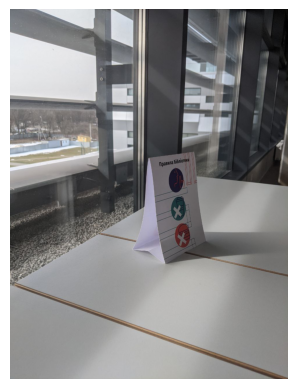

In [27]:
##### YOUR CODE STARTS #####
img2_path = './img2.jpg'
##### YOUR CODE ENDS #####
image2 = cv.imread(img2_path)
cv2_imshow(image2)

Implement the function that constructs a perspective shift matrix and apply it to the image.

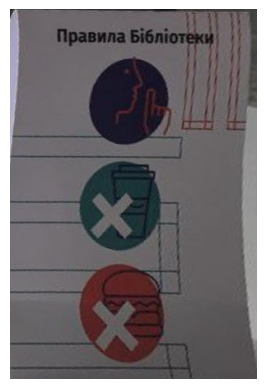

In [28]:
##### YOUR CODE STARTS #####
def get_perspective_transform_matrix(source, destination):
    A = np.zeros((8, 8))
    b = np.zeros(8)
    for i in range(4):
        x, y = source[i][0], source[i][1]
        u, v = destination[i][0], destination[i][1]
        A[2*i]   = [x, y, 1, 0, 0, 0, -x*u, -y*u]
        A[2*i+1] = [0, 0, 0, x, y, 1, -x*v, -y*v]
        b[2*i]   = u
        b[2*i+1] = v
    coeffs = np.linalg.solve(A, b)
    H = np.array([
        [coeffs[0], coeffs[1], coeffs[2]],
        [coeffs[3], coeffs[4], coeffs[5]],
        [coeffs[6], coeffs[7], 1.0]
    ])
    return H

rows, cols, ch = image2.shape

source_points = np.float32([[475, 515], [640, 490], [675, 800], [535, 875]])
destination_points = np.float32([[0, 0], [300, 0], [300, 450], [0, 450]])

perspective_shift_m = get_perspective_transform_matrix(source_points, destination_points)

transformed = cv.warpPerspective(image2, perspective_shift_m, (300, 450))
cv2_imshow(transformed)
##### YOUR CODE ENDS #####

Compare your result with one obtained with the built-in `getPerspectiveTransform()` opencv funtion.

Custom matrix:
[[ 9.55901974e-01 -1.59316996e-01 -3.72005185e+02]
 [ 1.05075722e-01  6.93499762e-01 -4.07063345e+02]
 [-6.44862061e-04 -9.85015906e-05  1.00000000e+00]]

OpenCV matrix:
[[ 9.55901974e-01 -1.59316996e-01 -3.72005185e+02]
 [ 1.05075722e-01  6.93499762e-01 -4.07063345e+02]
 [-6.44862061e-04 -9.85015906e-05  1.00000000e+00]]


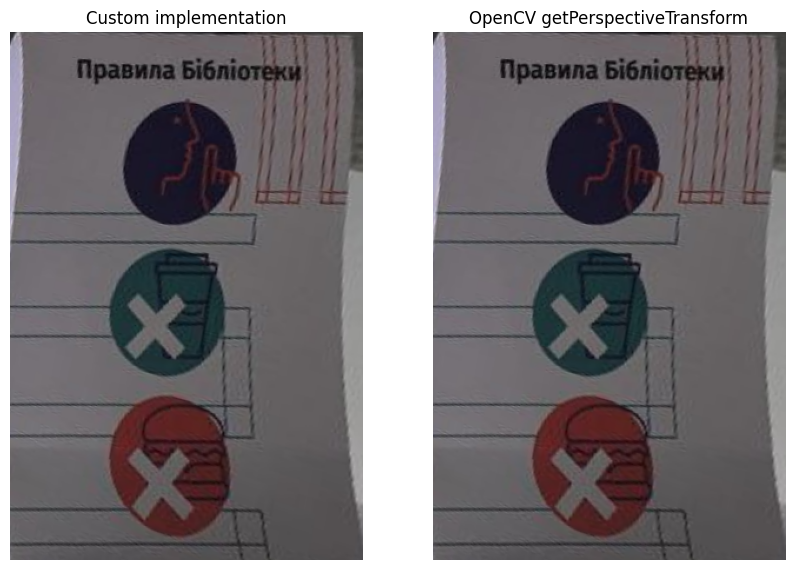

In [29]:
##### YOUR CODE STARTS #####
opencv_matrix = cv.getPerspectiveTransform(source_points, destination_points)
print('Custom matrix:')
print(perspective_shift_m)
print('\nOpenCV matrix:')
print(opencv_matrix)

transformed_opencv = cv.warpPerspective(image2, opencv_matrix, (300, 450))

fig, axes = plt.subplots(1, 2, figsize=(10, 7))
axes[0].imshow(cv.cvtColor(transformed, cv.COLOR_BGR2RGB))
axes[0].set_title('Custom implementation')
axes[0].axis('off')
axes[1].imshow(cv.cvtColor(transformed_opencv, cv.COLOR_BGR2RGB))
axes[1].set_title('OpenCV getPerspectiveTransform')
axes[1].axis('off')
plt.show()
##### YOUR CODE ENDS #####

### 2.2 Composition of transformations

Apply the following transformations to the original image in the specified order and observe the results displayed side-by-side.

1) Scaling by $(1.5, 2)$, rotation by $18^\circ$ and translation by $(10, 15)$.  
2) Translation by $(10, 15)$, scaling by $(1.5, 2)$, rotation by $18^\circ$.

---------------------------
Scaling by  (1.5,2) , rotation by  18∘  and translation by  (10,15)
---------------------------


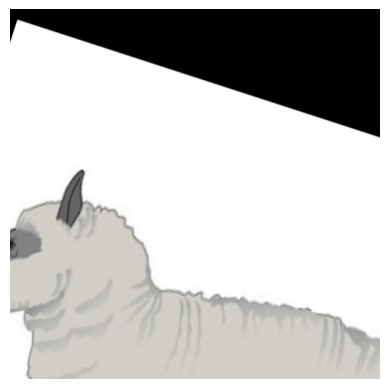

---------------------------
Translation by  (10,15) , scaling by  (1.5,2) , rotation by  18∘
---------------------------


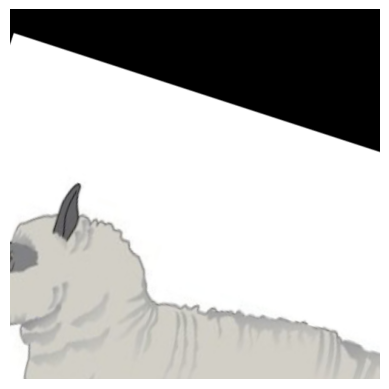

In [30]:
print("---------------------------")
print("Scaling by  (1.5,2) , rotation by  18\u2218  and translation by  (10,15)")
print("---------------------------")

##### YOUR CODE STARTS #####
theta = np.radians(18)

# Scaling matrix (homogeneous 3x3)
S = np.array([
    [1.5, 0,   0],
    [0,   2.0, 0],
    [0,   0,   1]
], dtype=np.float64)

# Rotation matrix (homogeneous 3x3)
R = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0,              0,             1]
], dtype=np.float64)

# Translation matrix (homogeneous 3x3)
T = np.array([
    [1, 0, 10],
    [0, 1, 15],
    [0, 0,  1]
], dtype=np.float64)

# Order 1: Scale -> Rotate -> Translate
M1 = T @ R @ S
img1_path = "./sheep.png"
image1 = cv.imread(img1_path)
image1 = cv.resize(image1, (500, 500))

result1 = cv.warpAffine(image1, M1[:2], (500, 500))
cv2_imshow(result1)
##### YOUR CODE ENDS #####

print("---------------------------")
print("Translation by  (10,15) , scaling by  (1.5,2) , rotation by  18\u2218")
print("---------------------------")

##### YOUR CODE STARTS #####
# Order 2: Translate -> Scale -> Rotate
M2 = R @ S @ T

result2 = cv.warpAffine(image1, M2[:2], (500, 500))
cv2_imshow(result2)
##### YOUR CODE ENDS #####

Do the outputs coincide? Is it possible to obtain same/different result changing the order of transformations? Which conditions should be met? Derive it theoretically.

The outputs **do not coincide**. Matrix multiplication is not commutative in general, i.e. $AB \neq BA$.

In the first case (Scale $\to$ Rotate $\to$ Translate), the combined matrix is $M_1 = T \cdot R \cdot S$. The image is first scaled, then rotated, and finally shifted. The translation is applied in the already-rotated coordinate frame.

In the second case (Translate $\to$ Scale $\to$ Rotate), the combined matrix is $M_2 = R \cdot S \cdot T$. The image is first shifted, then that shifted result is scaled (which also scales the translation offset), and then everything is rotated.

The results would coincide only if the transformation matrices commute. Two matrices $A$ and $B$ commute if $AB = BA$. Specific conditions:
- Two rotations always commute (in 2D): $R(\alpha) R(\beta) = R(\beta) R(\alpha) = R(\alpha + \beta)$
- Two translations always commute: $T(a, b) T(c, d) = T(c, d) T(a, b) = T(a+c, b+d)$
- Uniform scaling ($s_x = s_y = s$) commutes with rotation
- In general, scaling does **not** commute with rotation when $s_x \neq s_y$, and translation does **not** commute with either scaling or rotation

In our case, $s_x = 1.5 \neq s_y = 2$, so scaling does not commute with rotation, and translation does not commute with either. Hence the two orderings produce different results.

# Task 3

In [31]:
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

It is a widely used technique in Computer Vision that involves filling in missing or corrupted parts of an image in a visually plausible way.
This task explores a simple approach to solving this problem using **grayscale images** for easier mathematical representation.  

In NumPy, a **grayscale image** is represented as a **2D matrix**, where each element corresponds to the intensity of a pixel $I_{gray} \in \mathbb{R}^{H \times W}$,where $H$ and $W$ are the image height and width, respectively.

```python
gray_image = np.array([
    [0, 128, 255],
    [64, 192, 255],
    [32, 160, 240]
])
```

In contrast, a **color image (RGB)** is a **3D matrix**, where each pixel has three intensity values corresponding to the Red, Green, and Blue channels $
I_{color} \in \mathbb{R}^{H \times W \times 3}$

```python
color_image = np.array([
    [[0, 0, 0], [128, 128, 128], [255, 255, 255]],
    [[64, 64, 64], [192, 192, 192], [255, 255, 255]],
    [[32, 32, 32], [160, 160, 160], [240, 240, 240]]
])
```

By working with grayscale images, we reduce the problem to single-channel interpolation, making it easier to comprehend at the beginning

One of the simplest image inpainting methods for small missing areas is **neighbor averaging**, where a missing pixel is restored by computing the average value of its known neighboring pixels.

For a missing pixel $I(x, y)$, its value can be estimated as:

$$
I(x, y) = \frac{1}{|𝒩(x, y)|} \sum_{(i,j) \in 𝒩(x, y)} I(i, j)
$$

where:  
- $𝒩(x, y)$ is the set of known neighboring pixels around $(x, y)$  
- $|𝒩(x, y)|$ is the number of valid neighbors  
- $I(i, j)$ is the intensity value of a neighboring pixel

---

The set of known neighboring pixels $𝒩(x, y)$ depends on:
* whether we consider 4-connectivity (direct neighbors only):
$$
𝒩_{4}(x, y) = \{ I(x-1, y), I(x+1, y), I(x, y-1), I(x, y+1) \}
$$

* or 8-connectivity (including diagonal neighbors):
$$
𝒩_{8}(x, y) = \{ I(x-1, y-1), I(x-1, y), I(x-1, y+1), I(x, y-1), I(x, y+1), I(x+1, y-1), I(x+1, y), I(x+1, y+1) \}
$$

---

In a **3×3 grid**, the missing pixel at $(1,1)$ is restored using its **top, bottom, left, and right** neighbors:
$$
I(1,1) = \frac{I(0,1) + I(1,0) + I(1,2) + I(2,1)}{4}
$$

With **all 8 neighbors (including those on the angles)**, the missing pixel is estimated as:

$$
I(1,1) = \frac{I(0,0) + I(0,1) + I(0,2) + I(1,0) + I(1,2) + I(2,0) + I(2,1) + I(2,2)}{8}
$$


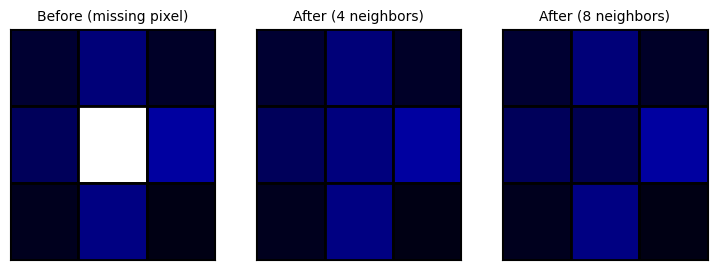

In [32]:
# 3x3 image with a missing center pixel
original_image = np.array([
    [50, 120, 40],
    [90, None, 160],
    [30, 130, 20]
], dtype=object)

# Restore using only direct (4) neighbors
direct_neighbors = [original_image[i, j] for i, j in [(0,1), (1,0), (1,2), (2,1)] if original_image[i, j] is not None]
restored_image_4 = original_image.copy()
restored_image_4[1, 1] = int(np.mean(direct_neighbors))

# Restore using all (8) neighbors
all_neighbors = [original_image[i, j] for i in range(3) for j in range(3) if original_image[i, j] is not None]
restored_image_8 = original_image.copy()
restored_image_8[1, 1] = int(np.mean(all_neighbors))

def plot_image(image, title, ax):
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)

    for i in range(3):
        for j in range(3):
            value = image[i, j]
            color = (0, 0, value / 255) if value is not None else (1, 1, 1)  # white for missing pixel
            rect = patches.Rectangle((j, 2 - i), 1, 1, facecolor=color, edgecolor='black', linewidth=2)
            ax.add_patch(rect)

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
plot_image(original_image, "Before (missing pixel)", axs[0])
plot_image(restored_image_4, "After (4 neighbors)", axs[1])
plot_image(restored_image_8, "After (8 neighbors)", axs[2])
plt.show()


**But what if multiple pixels are missing?**  

When multiple adjacent pixels are missing, we can no longer use simple **neighbor averaging** because some missing pixels depend on others that are also unknown. Instead, we need to set up a **system of linear equations**, where each missing pixel is expressed in terms of its known neighbors and other missing pixels.  


### 3.1

Let's consider a simple case where we have a **2×2 missing block** inside a larger image. Your task is to write the system of equations in the form and solve for the missing pixel values.

---

We have a 5×5 grayscale image with the center 2×2 pixels are missing:

$$
\begin{bmatrix}
100 & 115 & 130 & 140 & 150 \\
110 & \mathbf{?} & \mathbf{?} & 145 & 155 \\
115 & \mathbf{?} & \mathbf{?} & 150 & 160 \\
120 & 135 & 140 & 155 & 165 \\
125 & 140 & 145 & 160 & 170
\end{bmatrix}
$$

We can assign variables to the missing pixels $
X_1 = I(1,1), \quad X_2 = I(1,2), \quad X_3 = I(2,1), \quad X_4 = I(2,2)$. Each missing pixel is estimated as the average of its neighbors.

---
1. Write the system of equations for the four unknowns $X_1, X_2, X_3, X_4$ using the given pixel values.
2. Construct the matrix equation $A X = B$, where $A$ is the coefficient matrix, $X$ is the vector of unknowns, $B$ is the vector of known values.
3. Solve for $X$ using `NumPy linalg solver`.

To help, here are the (4) neighbors of each missing pixel:

- $X_1$ (Row 1, Col 1): uses 110, 115, X_2, X_3
- $X_2$ (Row 1, Col 2): uses 130, 145, X_1, X_4
- $X_3$ (Row 2, Col 1): uses 115, 135, X_1, X_4
- $X_4$ (Row 2, Col 2): uses 150, 140, X_2, X_3


**Your theoretical formulation of the system of equations:**

---

We have such matrix
$$
\begin{bmatrix}
100 & 115 & 130 & 140 & 150 \\
110 & X1 & X2 & 145 & 155 \\
115 & X3 & X4 & 150 & 160 \\
120 & 135 & 140 & 155 & 165 \\
125 & 140 & 145 & 160 & 170
\end{bmatrix}
$$
Let`s consider 4-connectivity. Derivation of equations:
1. 
$$X_1 = \frac{110 + 115 + X_2 + X_3}{4}$$
$$4X_1 - X_2 - X_3 + 0X_4= 225$$

2. 
$$X_2 = \frac{130 + 145 + X_1 + X_4}{4}$$
$$ -X_1 + 4X_2 + 0X_3 - X_4 = 275$$

3. 
$$X_3 = \frac{115 + 135 + X_1 + X_4}{4}$$
$$ -X_1 + 0X_2 + 4X_3 - X_4 = 250$$

4. 
$$X_4 = \frac{150 + 140 + X_2 + X_3}{4}$$
$$ 0X_1 -X_2 - X_3 + 4X_4 = 290$$

Let`s construct augumented matrix out of the coefficients: 
$$
\begin{bmatrix}
 4 & -1 & -1 &  0 &  |&  225\\
-1 &  4 &  0 & -1 &  |&  275\\
-1 &  0 &  4 & -1 &  |&  250\\
 0 & -1 & -1 &  4&  |&  290
\end{bmatrix} 
$$
---

In [33]:
### YOUR CODE SOLUTION START

# Define the coefficient matrix A based on the equations derived from neighbor averaging
A = np.array([
    [ 4, -1, -1,  0],
    [-1,  4,  0, -1],
    [-1,  0,  4, -1],
    [ 0, -1, -1,  4]
],)

# Define the right-hand side B based on known neighbor values
B = np.array([225, 275, 250, 290])

### YOUR CODE SOLUTION END

X = np.linalg.solve(A, B)
assert np.allclose(X, np.array([121.45833333, 133.54166667, 127.29166667, 137.70833333]), atol=1e-6), "Assertion failed: Computed values do not match expected values"

### 3.2

Implement an actual image inpainting algorithm that reconstructs missing pixel values using a linear system approach. Compare results with manual implementation of Gaussian elimination and NumPy solver.

Functions you need to implement:
- `construct_linear_system(pixel_matrix, damaged_coords)`  
- `solve_linear_system(A, b, method='numpy')`

Helper functions (already provided):
- `to_grayscale(img)`
- `get_pixel_matrix(img)`
- `set_pixel_matrix(img, pixel_matrix)`
- `create_damaged_matrix(pixel_matrix, num_blocks=5, block_size=20)`
- `complete_solution(img_gray, damaged_matrix, damaged_coords, method='numpy')`

Parameters `num_blocks` and `block_size` can be changed and customized to your preference (but we do not recommend choosing large values due to the probability of long computations).

An example of a potential result:

![image.png](attachment:image.png)

In [34]:
# Convert an image to grayscale
def to_grayscale(img):
    return img.convert("L")

# Get the pixel intensity matrix
def get_pixel_matrix(img):
    width, height = img.size
    return [[img.getpixel((x, y)) for x in range(width)] for y in range(height)]

# Set pixel values from a matrix back to an image
def set_pixel_matrix(img, pixel_matrix):
    width, height = img.size
    for y in range(height):
        for x in range(width):
            img.putpixel((x, y), int(pixel_matrix[y][x]))
    return img

# Generate damaged regions in an image
def create_damaged_matrix(pixel_matrix, num_blocks=5, block_size=20):
    height, width = len(pixel_matrix), len(pixel_matrix[0])
    damaged_coords = []
    damaged_matrix = [row[:] for row in pixel_matrix]

    for _ in range(num_blocks):
        rand_x = random.randint(0, width - block_size)
        rand_y = random.randint(0, height - block_size)
        for y in range(rand_y, rand_y + block_size):
            for x in range(rand_x, rand_x + block_size):
                damaged_coords.append((y, x))
                damaged_matrix[y][x] = 0

    return damaged_matrix, damaged_coords

#### 3.2.1

In [35]:
# Construct the linear system Ax = B for missing pixels
def construct_linear_system(pixel_matrix, damaged_coords):
    """
    Explanations:
    - This function constructs a linear system where each missing pixel is represented by an equation.
    - Each missing pixel is expressed as the average of its valid neighboring pixels.
    - The mapping 'var_index' assigns a unique index to each missing pixel, allowing it to be referenced in matrix form.

    Example:
    var_index = {
        (2, 3): 0, # first missing pixel -> X_0
        (3, 4): 1, # second missing pixel -> X_1
        (5, 2): 2  # third missing pixel -> X_2
    }

    Returns:
    - A (list of lists): Coefficient matrix representing the system of equations.
    - b (list): Right-hand side vector containing known pixel values.
    """
    height, width = len(pixel_matrix), len(pixel_matrix[0])
    var_index = {coord: i for i, coord in enumerate(damaged_coords)}
    n = len(damaged_coords)
    A = [[0] * n for _ in range(n)]
    b = [0] * n

    ### YOUR CODE SOLUTION START
    damaged_set = set(damaged_coords)

    for coord in damaged_coords:
        i = var_index[coord]
        y, x = coord
        #neighbors = [(y-1, x-1), (y-1, x), (y-1, x+1),(y,x-1),(y,x+1),(y+1, x-1), (y+1, x), (y+1, x+1)] 
        neighbors = [(y-1, x), (y+1, x), (y, x-1), (y, x+1)] # here is 4-connectivity and I chose to use it as primar - but there is small at least visual difference
        valid_neighbors = [(ny, nx) for ny, nx in neighbors
                           if 0 <= ny < height and 0 <= nx < width]
        num_valid = len(valid_neighbors)
        A[i][i] = num_valid

        for ny, nx in valid_neighbors:
            if (ny, nx) in damaged_set:
                j = var_index[(ny, nx)]
                A[i][j] -= 1.0
            else:
                b[i] += pixel_matrix[ny][nx]
    ### YOUR CODE SOLUTION END

    return A, b

#### 3.2.2

In [ ]:
# Solve the linear system using Gaussian elimination or NumPy
def solve_linear_system(A, b, method='numpy'):
    """
    Solves the linear system Ax = B.

    Parameters:
    - A (list of lists): Coefficient matrix.
    - b (list): Right-hand side vector.
    - method (str): 'numpy' to use NumPy solver, 'gaussian' to use manual Gaussian elimination.

    Returns:
    - x (list): Solution vector containing the restored pixel values.
    """
    if method == 'numpy':
        return np.linalg.solve(A, b)
    else:
        n = len(A)
        x = [0] * n

        ### YOUR CODE SOLUTION START
        aug = [A[i][:] + [b[i]] for i in range(n)]
        for col in range(n):
            max_row = col
            for row in range(col + 1, n):
                if abs(aug[row][col]) > abs(aug[max_row][col]):
                    max_row = row
            aug[col], aug[max_row] = aug[max_row], aug[col]
            pivot = aug[col][col]
            for row in range(col + 1, n):
                factor = aug[row][col] / pivot
                for k in range(col, n + 1):
                    aug[row][k] -= factor * aug[col][k]
        for row in range(n - 1, -1, -1):
            x[row] = aug[row][n]
            for k in range(row + 1, n):
                x[row] -= aug[row][k] * x[k]
            x[row] /= aug[row][row]
        ### YOUR CODE SOLUTION END
        return x

In [37]:
def complete_solution(img_gray, damaged_matrix, damaged_coords, method='numpy'):
  try:
      solution = solve_linear_system(A, b, method)
  except ValueError as e:
      print("Error solving the system:", e)
      solution = None

  # Apply the reconstructed pixel values
  if solution is not None:
      restored_matrix = [row[:] for row in damaged_matrix]
      for i, (y, x) in enumerate(damaged_coords):
          restored_matrix[y][x] = int(solution[i])

      # Create visualization
      restored_img = set_pixel_matrix(img_gray.copy(), restored_matrix)
      damaged_img = set_pixel_matrix(img_gray.copy(), damaged_matrix)
      highlighted_matrix = [row[:] for row in damaged_matrix]
      for (y, x) in damaged_coords:
          highlighted_matrix[y][x] = 255
      highlighted_img = set_pixel_matrix(img_gray.copy(), highlighted_matrix)

      # Display results
      fig, axs = plt.subplots(1, 3, figsize=(15, 5))
      axs[0].imshow(img_gray, cmap='gray')
      axs[0].set_title("Original Image")
      axs[1].imshow(highlighted_img, cmap='gray')
      axs[1].set_title("Damaged Image")
      axs[2].imshow(restored_img, cmap='gray')
      axs[2].set_title("Reconstructed Image")

      for ax in axs:
          ax.axis("off")

      plt.show()

**Example of use**

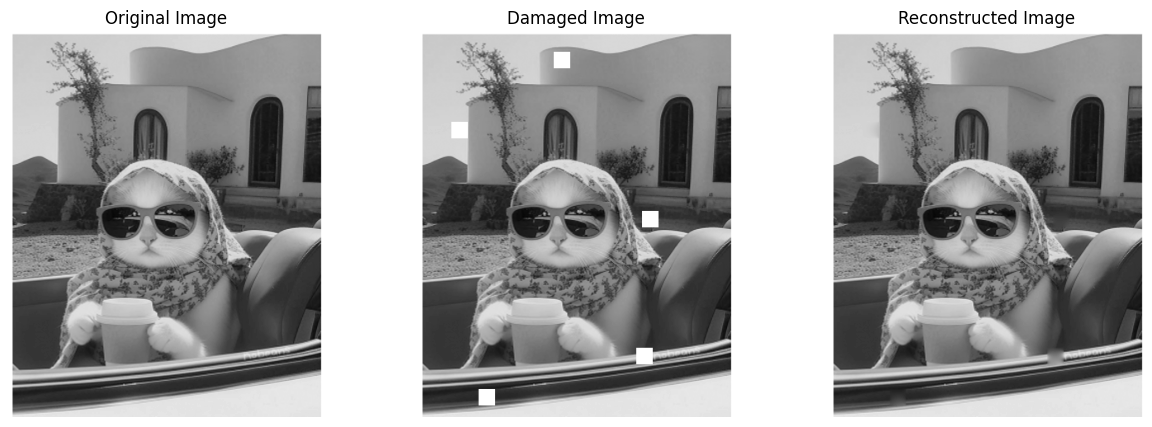

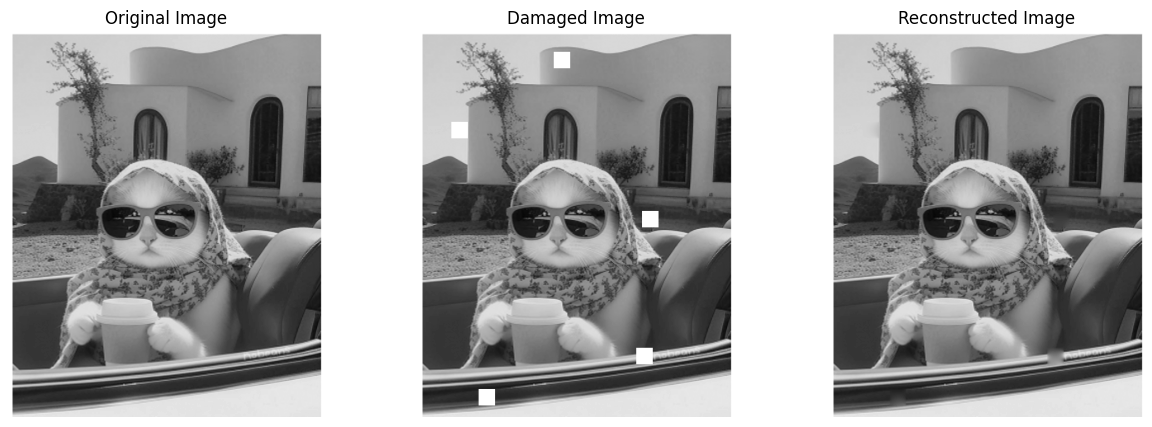

In [ ]:
# Load and preprocess the image
img = Image.open("fancy_car.png")
img_gray = to_grayscale(img)
pixel_matrix = get_pixel_matrix(img_gray)

# Create damaged image
num_blocks= 5 # number of damages
block_size= 20 # pixel size of damages
height, width = len(pixel_matrix), len(pixel_matrix[0])
damaged_matrix, damaged_coords = create_damaged_matrix(pixel_matrix, num_blocks, block_size)

# Construct the linear system
A, b = construct_linear_system(pixel_matrix, damaged_coords)

# Solve and visualize
complete_solution(img_gray, damaged_matrix, damaged_coords)
complete_solution(img_gray, damaged_matrix, damaged_coords, method='gaussian')

**Your thoughts and conclusions:**

---
Very beautiful and easy to understand that every pixel is linear equation. And each equation can have at most 4 variables (if we are using 4-connectivity and 8 otherwise).

I could not see big difference between 4-connectivity and 8-connectivity visually.

Both solvers produced identical results, which visually confirms the implementation. The NumPy solver is significantly faster in practice, the manual Gaussian elimination is very slow it has three for loops so its $O(n^3)$. For example the current number of blocks and their size (5, 20) manual implementation did in four minutes while NumPy managed to do it in seconds. in A each row has at most 4 nonzero entries, the diagonal entry equals the total number of neighbors of that pixel, while each if nonzero than −1 (we could see it on small example but it works for every damage). As long as at least one neighbor of a missing pixel is a known pixel, the diagonal entry is larger than the sum of abs values in that row. This means any row cannnt be expressed as a linear combination of the other, so the matrix is always invertible and the system has unique solution.

The bigger the blocks the worse for reconstruction because the image becomes more blury and patterns disappear. If there are many small blocks than reconstruction still looks believable.

The biggest insight is that many problems, for example, image processing can be reduced to standard linear algebra.

---

**Additional questions:**
1. What other methods do you know to solve a system of linear equations?
2. What happens if the damaged pixels are located at the edges of the image? How will this affect the equation?
3. How will the problem change if we take diagonal neighbors into account when calculating the average?
4. Why does the algorithm work well for small damage but is ineffective for large areas?
5. How would you improve the approach to repair more complex damage (e.g., entire missing objects)?
---

1.  a. the easiest method that works only for 2D or 3D - visualize and find intersection. 
    b. LU Decomposition. Factorize and get: A = LU. solve two triangular systems. 
    c. Cramers rule: $x_i = det(A_i)/det(A)$.  where Ai - A with the i-th column replaced by b
    d. For small system substitution method can be used.

2. If demages pixels located there they have few valid neighbors. For a pixel on the image boundary, only 3 neighbors are available if to the side and if to the corner than only 2. So the equation will have fewer unknowns. And pixel will be estimated with less accuracy. 


3. There are more known pixels, providing more constraints. The solution may look smoother, because diagonal neighbors spread information across a wider area. This is particularly beneficial for diagonal edges or textures. The trade-off is a higher memory footprint and marginally longer solve time. Additionally, having more neighbors per equation increases the diagonal value of A (from 4 to up to 8) which makes the system numerically more stable.

4. The algorithm works well for small damage, most neighbors of a missing pixel are known and the equations are constrained by image values and the solution is reasonable. The bigger damaged regon, the more missing pixels reference other missing pixels as neighbors. The system is still solvable it remains non-singular but the results turns out with even less texture or detail. The larger and more the damaged pixels areas, the more the reconstruction of image looks blurry.

5. I would try to use another approach:

- Harmonic inpainting - (information taken from: Inoue, Cabella & Komatsu, 2008) Reconstructs missing pixel values by minimizing an energy functional that balances two things which are: faithfulness to the known data and smoothness of the reconstructed region. The smoothness condition if just to solve Laplaces equation inside the damaged area, using the boundary between known and unknown pixels as the constraint.

- Chui-Mhaskar - reconstructs missing data using a multiresolution. It fits a simplest function from a spline wavelet space to the known pixels and extends it into the damaged region.

- Image Inpainting Method Based on Mixed Median - the same as our method but uses a weighted median of its neighbors, so it doeasn`t account for outliers.

- PatchMatch thing that many people did manually in photoshop - find visually similar patches elsewhere in the image and copies them in. This preserves texture and works well for large damaged regions. 

- GANs repair images by having two neural networks "compete" to create a realistic patch in one shot, + judges whether the result look real.

- Diffusion Models work by gradually refined "denoising," turning random static into a coherent object that matches the surrounding context.

---

**You can explore more advanced approaches with the same core idea:**
- [On Surface Completion and Image Inpainting by Biharmonic Functions](https://onlinelibrary.wiley.com/doi/10.1155/2018/3950312)
- [Harmonic Inpainting of the Cosmic Microwave Background Sky: Formulation and Error Estimate](https://arxiv.org/abs/0804.0527)
- [Image Inpainting Method Based on Mixed Median](https://ieeexplore.ieee.org/document/8858556)



## Summary

To summarize everything you have learnt in this lab assignment, answer the questions below.

### How its shape and values affect the resulting image? What is a shape of a typical transformation matrix that is applied to images; which factors affect its shape?

A transformation matrix controls **where each output pixel samples from** in the source image, so both its shape and numeric values directly affect the visual result.

For 2D images, common matrix shapes are:
- **$2\times 3$ (affine)** for translation, rotation, scaling, shearing, and reflection.
- **$3\times 3$ (projective / homography)** for perspective effects.

How values affect the image:
- Diagonal entries mainly control scaling (zoom in/out).
- Off-diagonal entries control rotation and shear.
- Last column in affine form controls translation.
- In a $3\times 3$ matrix, the last row introduces perspective division, which creates depth-like distortion (parallel lines may converge).

What affects the matrix shape:
- **Type of transform needed** (affine vs perspective).
- **Coordinate model** (Cartesian vs homogeneous coordinates).
- **Dimensionality of data** (2D image transforms vs higher-dimensional transforms).

So, the matrix shape determines what class of geometric effects is possible, while the matrix values determine the exact strength and direction of those effects.

### What can be a result of composition of transformations?

A composition of transformations is a single transformation obtained by multiplying the individual transformation matrices together. For example, applying scaling $S$, then rotation $R$, then translation $T$ yields $M = T \cdot R \cdot S$. The resulting matrix $M$ combines all three effects into one operation.

Key observations:
- The composition is **order-dependent**: $T \cdot R \cdot S \neq R \cdot S \cdot T$ in general, because matrix multiplication is not commutative.
- The result is still a transformation of the same type as the most general factor. Composing only affine transforms (scaling, rotation, shearing, translation) gives another affine transform ($2 \times 3$ matrix). Composing with a perspective transform gives a projective transform ($3 \times 3$ matrix).
- Composition can produce effects that none of the individual transformations have on their own. For instance, scaling by different factors followed by rotation produces a shearing-like distortion that neither pure scaling nor pure rotation would create alone.

### What is a perspective shift transformation in terms of geometry?



A perspective transformation is a projective mapping between two planes it simulates how a flat surface looks when photographed from an angle. It preserves straight lines but not parallelism or distances. It is a 3×3 matrix in homogeneous coordinates: the top-left 2×2 block handles rotation and scaling, the third column handles translation, and the bottom row is what makes it perspective rather than affine it introduces division by a varying denominator, causing objects to shrink with distance. The matrix has 8 degrees of freedom (the 9th entry fixed to 1), so exactly 4 point correspondences are needed to determine it.